# Running Palace Simulations: Microstrip

[Palace](https://awslabs.github.io/palace/) is an open-source 3D electromagnetic simulator supporting eigenmode, driven (S-parameter), and electrostatic simulations. This notebook demonstrates using the `gsim.palace` API to run a driven simulation on a microstrip transmission line with via ports.

**Requirements:**

- IHP PDK: `uv pip install ihp-gdsfactory`
- [GDSFactory+](https://gdsfactory.com) account for cloud simulation

### Load a pcell from IHP PDK

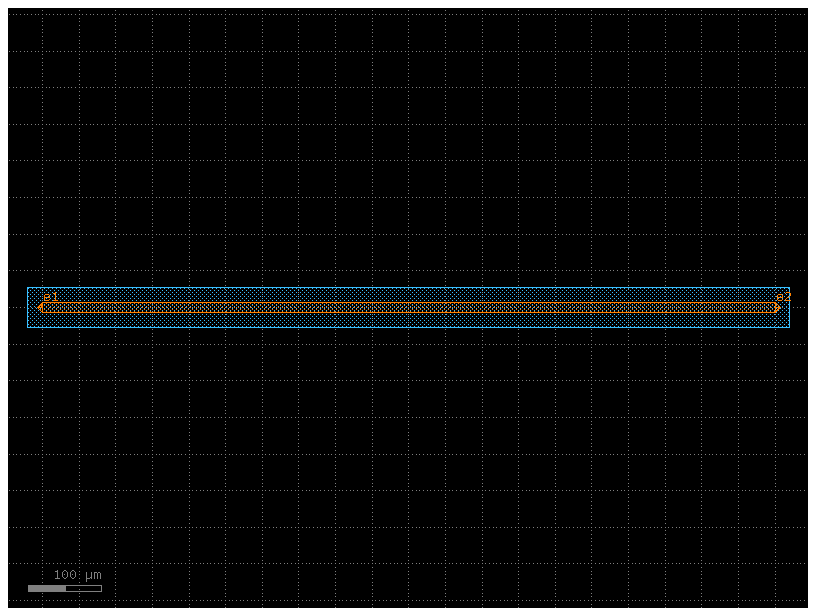

In [1]:
import gdsfactory as gf
from ihp import LAYER, PDK, cells

PDK.activate()

c = gf.Component()
r1 = c << cells.straight_metal(length=1000, width=14)

r = c.get_region(layer=LAYER.TopMetal2drawing)
r_sized = r.sized(+20000)
c.add_polygon(r_sized, layer=LAYER.Metal1drawing)


c.add_ports(r1.ports)

cc = c.copy()
cc.draw_ports()
cc

### Configure and run simulation with DrivenSim

In [2]:
from gsim.palace import DrivenSim

# Create simulation object
sim = DrivenSim()

# Set output directory
sim.set_output_dir("./palace-sim-microstrip")

# Set the component geometry
sim.set_geometry(c)

# Configure layer stack from active PDK
sim.set_stack(substrate_thickness=2.0, air_above=300.0)

# Configure via ports (Metal1 ground plane to TopMetal2 signal)
for port in c.ports:
    sim.add_port(port.name, from_layer="metal1", to_layer="topmetal2", geometry="via")

# Configure driven simulation (frequency sweep for S-parameters)
sim.set_driven(fmin=1e9, fmax=100e9, num_points=300)

# Validate configuration
print(sim.validate_config())

Validation: PASSED


In [3]:
# Generate mesh (presets: "coarse", "default", "fine")
sim.mesh(preset="default")

Mesh Summary
Dimensions: 1140.0 x 154.0 x 318.3 µm
Nodes:      6,221
Elements:   46,926
Tetrahedra: 33,278
Edge length: 0.40 - 285.00 µm
Quality:    0.392 (min: 0.001)
SICN:       0.432 (all valid)
----------------------------------------
Volumes (3):
  - SiO2 [1]
  - passive [2]
  - air [3]
Surfaces (11):
  - metal1_xy [4]
  - metal1_z [5]
  - topmetal2_xy [6]
  - topmetal2_z [7]
  - P1 [8]
  - P2 [9]
  - SiO2__None [10]
  - SiO2__passive [11]
  - passive__None [12]
  - air__passive [13]
  - air__None [14]
----------------------------------------
Mesh:   palace-sim-microstrip/palace.msh

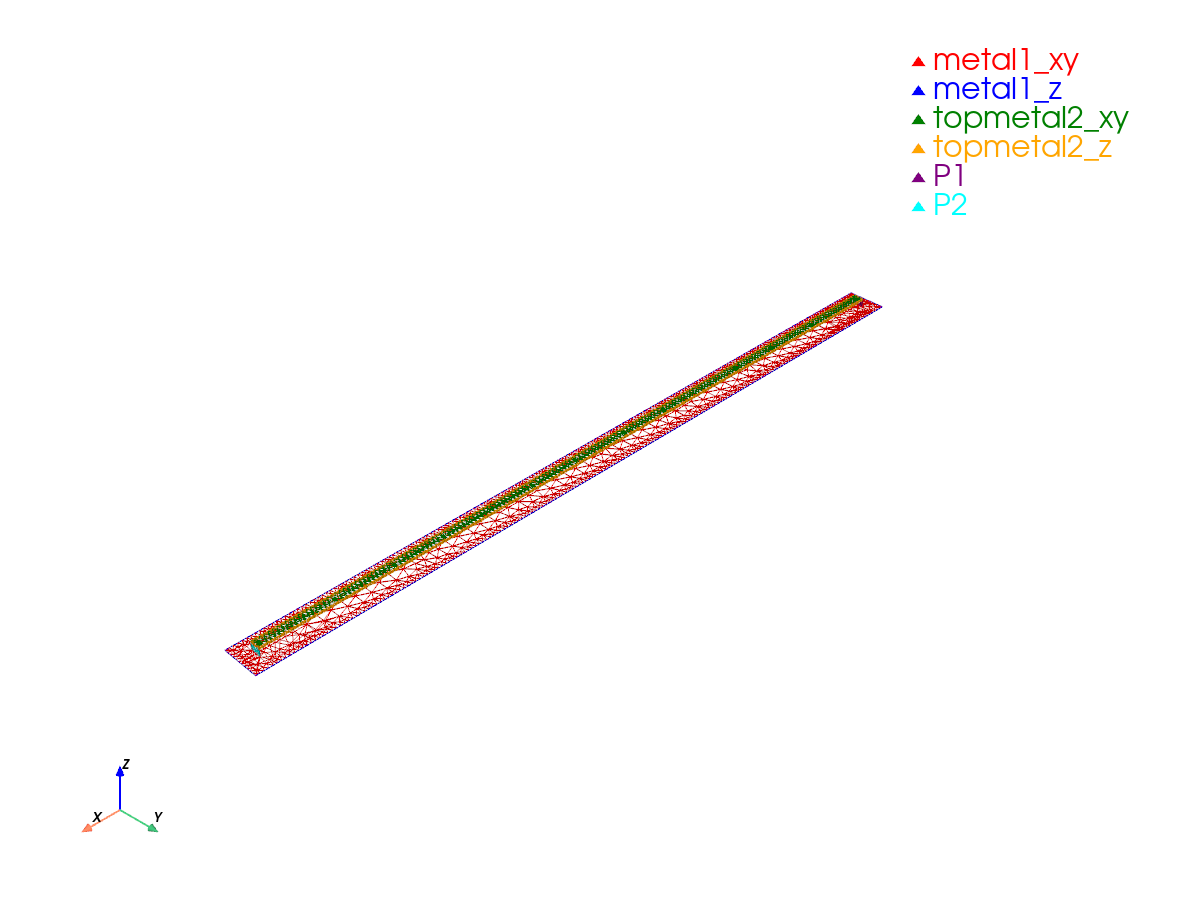

In [4]:
# Static PNG
sim.plot_mesh(show_groups=["metal", "P"])

### Run simulation on GDSFactory+ Cloud

In [5]:
# Run simulation on GDSFactory+ cloud
results = sim.run()

  palace-6b69b0ba  completed  4m 04s


Extracting results.tar.gz...
Downloaded 10 files to sim-data-palace-6b69b0ba


In [6]:
results.plot_interactive()

Port mapping: Port 1: e1, Port 2: e2


In [7]:
results.plot_interactive(phase=True)

Port mapping: Port 1: e1, Port 2: e2
